## Goal: 

Partition benchmark citing cases into subsets (special vs normal & older vs recent) for citator experiments.

### Steps:

1. Load data — Read citing_data.csv (291 cases) with fields: cluster_id, year_filed, court, num_authorities, citation_count, text_length, and authorities.

2. Split into special vs. normal cases — Cases were labeled "special" if they had num_authorities > 33 OR text_length > 70,000. This yielded:

    - 113 special cases
    - 178 normal cases

3. Split by recency — Each group was further split at a 1976 cutoff:

   - Special recent (≥1976): 84 cases
   - Normal recent (≥1976): 109 cases
   - Older (pre-1976): 98 cases

4. EDA — Computed descriptive stats and plotted histograms of year_filed and court for both the special and normal groups.

5. Save the output with case_type column to citing_data_with_case_type.csv

## Import libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

## Get the citing data

In [2]:
df = pd.read_csv("data/citing_data.csv")
df.head()

,cluster_id,year_filed,court,num_authorities,citation_count,text_length,authorities
0,100397,1924,scotus,25,184,13086,"{""85452"": {""citations"": [""1824 U.S.LEXIS 410"",..."
1,100409,1924,scotus,22,35,30854,"{""85797"": {""citations"": [""1832 U.S.LEXIS 489"",..."
2,100771,1926,scotus,36,565,19264,"{""85272"": {""citations"": [""17 U.S. 316"", ""1819 ..."
3,100887,1926,scotus,14,120,11413,"{""90040"": {""citations"": [""100 U.S. 313"", ""1879..."
4,100915,1926,scotus,2,4,10254,"{""96357"": {""citations"": [""1905 U.S.LEXIS 991"",..."


In [3]:
len(df)

291

## Separate special cases citing IDs 

- "num_authorities" > 33 OR "text_length" > 70,000

In [4]:
special_df = df[
    (df["num_authorities"] > 33)
    | (df["text_length"] > 70000)
]
len(special_df)

114

## Separate special vs normal and recent vs older cases

In [5]:
special_df_recent = special_df[special_df["year_filed"] >= 1976]
normal_df = df[~df["cluster_id"].isin(special_df["cluster_id"])]
normal_df_recent = normal_df[normal_df["year_filed"] >= 1976]

In [6]:
assert len(special_df) + len(normal_df) == len(df), "The number of special and normal cases should sum up to the total number of cases."

## Summary stats of special vs normal and recent vs older cases

In [7]:
print("total number of cases: ", len(df))

print("---")
print("number of older cases: ", len(df) - len(special_df_recent) - len(normal_df_recent))
print("number of recent cases: ", len(special_df_recent) + len(normal_df_recent))

print("---")
print("number of special cases: ", len(special_df))
print("number of recent special cases: ", len(special_df_recent))

print("---")
print("number of normal cases: ", len(normal_df))
print("number of recent normal cases: ", len(normal_df_recent))

total number of cases:  291
---
number of older cases:  98
number of recent cases:  193
---
number of special cases:  114
number of recent special cases:  85
---
number of normal cases:  177
number of recent normal cases:  108


## EDA on special cases

In [8]:
special_df["citation_count"].describe()

count      114.000000
mean      1142.087719
std       1951.719621
min          0.000000
25%         91.250000
50%        519.000000
75%       1206.250000
max      11290.000000
Name: citation_count, dtype: float64

In [9]:
special_df["num_authorities"].describe()

count    114.000000
mean      59.859649
std       35.925162
min       11.000000
25%       36.000000
50%       49.000000
75%       71.250000
max      195.000000
Name: num_authorities, dtype: float64

In [10]:
special_df["text_length"].describe()

count       114.000000
mean     156775.771930
std      131206.420129
min       19264.000000
25%       73953.500000
50%      111567.500000
75%      189217.500000
max      795687.000000
Name: text_length, dtype: float64

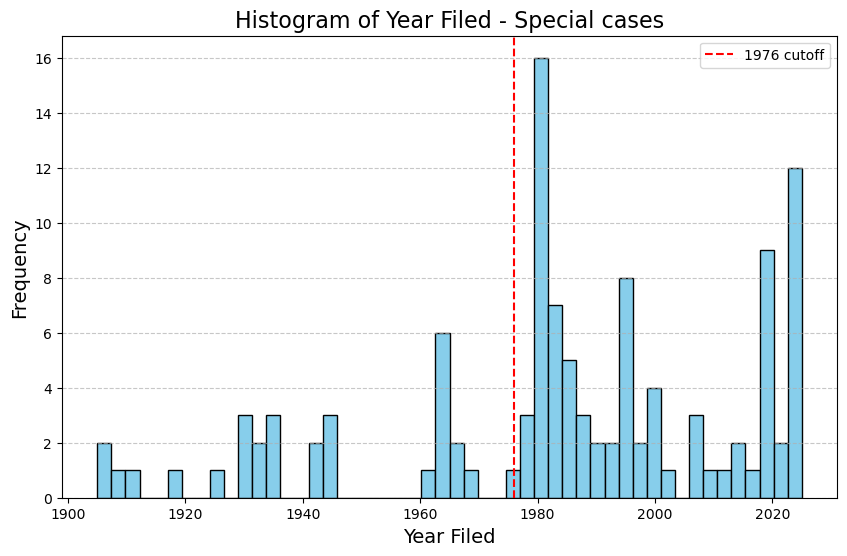

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(special_df["year_filed"], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Year Filed - Special cases', fontsize=16)
plt.axvline(x=1976, color='red', linestyle='--', label='1976 cutoff')
plt.legend()
plt.xlabel('Year Filed', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/var/folders/d9/3h7m7wc52kv6fgxmbyd8s0940000gn/T/ipykernel_49567/1197250729.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  special_df["court"] = pd.Categorical(special_df["court"], categories=sorted(special_df["court"].unique()), ordered=True)


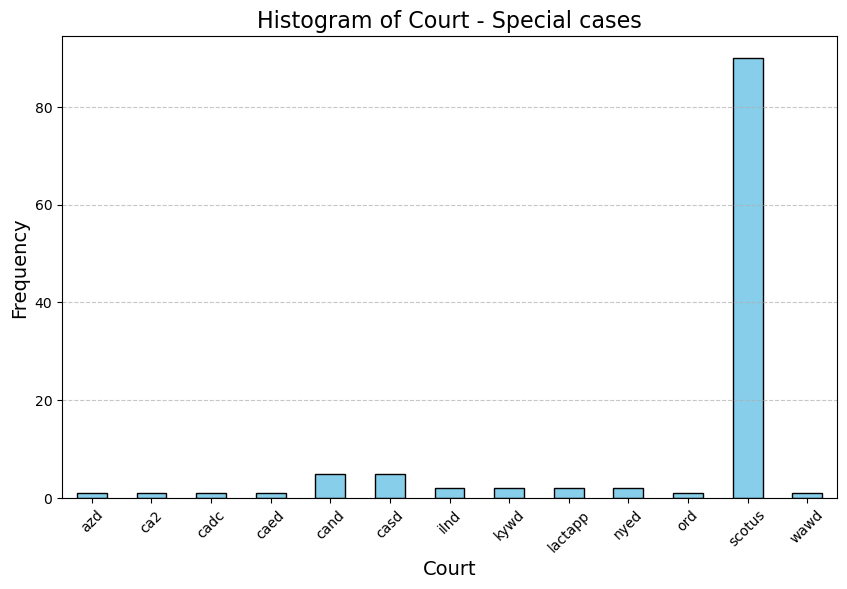

In [12]:
plt.figure(figsize=(10, 6))

# Convert 'court' column to categorical and sort categories for proper alignment
special_df["court"] = pd.Categorical(special_df["court"], categories=sorted(special_df["court"].unique()), ordered=True)

# Plot the histogram
special_df["court"].value_counts(sort=False).plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Histogram of Court - Special cases', fontsize=16)
plt.xlabel('Court', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

## EDA on normal cases

In [13]:
normal_df["citation_count"].describe()

count     177.000000
mean      182.943503
std       696.230302
min         0.000000
25%         0.000000
50%         8.000000
75%       119.000000
max      8614.000000
Name: citation_count, dtype: float64

In [14]:
normal_df["num_authorities"].describe()

count    177.000000
mean      16.192090
std        7.048319
min        1.000000
25%       11.000000
50%       15.000000
75%       21.000000
max       33.000000
Name: num_authorities, dtype: float64

In [15]:
normal_df["text_length"].describe()

count      177.000000
mean     25262.717514
std      15774.934640
min        342.000000
25%      13086.000000
50%      21673.000000
75%      34277.000000
max      69045.000000
Name: text_length, dtype: float64

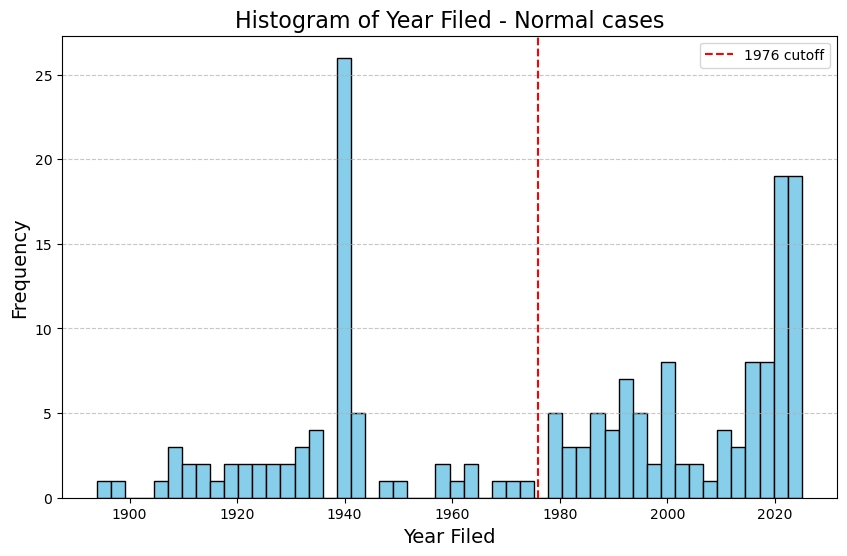

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(normal_df["year_filed"], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Year Filed - Normal cases', fontsize=16)
plt.axvline(x=1976, color='red', linestyle='--', label='1976 cutoff')
plt.legend()
plt.xlabel('Year Filed', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/var/folders/d9/3h7m7wc52kv6fgxmbyd8s0940000gn/T/ipykernel_49567/4227540156.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normal_df["court"] = pd.Categorical(normal_df["court"], categories=sorted(normal_df["court"].unique()), ordered=True)


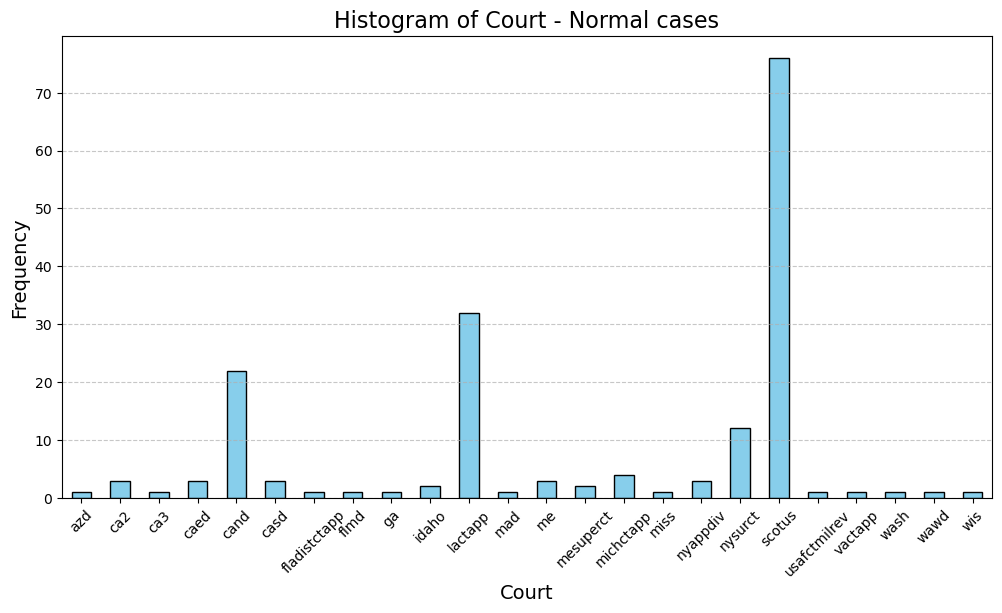

In [17]:
plt.figure(figsize=(12, 6))

# Convert 'court' column to categorical and sort categories for proper alignment
normal_df["court"] = pd.Categorical(normal_df["court"], categories=sorted(normal_df["court"].unique()), ordered=True)

# Plot the histogram
normal_df["court"].value_counts(sort=False).plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Histogram of Court - Normal cases', fontsize=16)
plt.xlabel('Court', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

## Modify df to tag the different cases (normal vs special and recent vs older) based on the cluster_id in the respective dfs

In [18]:
# Initialize a new column with default value "normal_older"
df["case_type"] = "normal_older"

# Update the case_type column based on cluster_id
df.loc[df["cluster_id"].isin(special_df_recent["cluster_id"]), "case_type"] = "special_recent"
df.loc[df["cluster_id"].isin(special_df["cluster_id"]) & ~df["cluster_id"].isin(special_df_recent["cluster_id"]), "case_type"] = "special_older"
df.loc[df["cluster_id"].isin(normal_df_recent["cluster_id"]), "case_type"] = "normal_recent"

# Verify the changes
df["case_type"].value_counts()

case_type
normal_recent     108
special_recent     85
normal_older       69
special_older      29
Name: count, dtype: int64

In [19]:
df.to_csv("data/citing_data_with_case_type.csv", index=False)